# Rice plant height and canopy width from 3D point clouds — Metatlas V1 workflow reproduction

**Paper:** *Balancing accuracy, completeness, and efficiency for rice 3D reconstruction through CBAM-UNet-based multi-view segmentation and camera configuration optimization* — Frontiers in Plant Science (2026), DOI [10.3389/fpls.2026.1882534](https://doi.org/10.3389/fpls.2026.1882534)

**Data/code:** Zenodo record [22016319](https://zenodo.org/records/22016319) **v2.2** (CC BY 4.0 for data/docs; MIT for `extract_phenotypic_traits.py`; GPLv3 + CC BY 4.0 inside `CBAM-UNet.zip`).

## What this notebook does (partial reproduction, executed)

1. Downloads the **eight representative rice point clouds** (4 cultivars V1–V4 × heading/maturity) that
   accompany the paper and verifies every file against the MD5 checksums published in the Zenodo record.
2. Runs the **authors' unmodified trait-extraction script** (`extract_phenotypic_traits.py`, MIT) to compute
   **plant height** (vertical z-extent, paper Eq. 10) and **canopy width** (PCA-aligned horizontal extent)
   for each cloud, in centimeters (metric scale was recovered by the authors from the 33 cm pot diameter).
3. Visualizes one point cloud with the measured traits annotated, tabulates and exports all results as CSV.
4. Verifies the deposited **CBAM-UNet 70-epoch checkpoint** (paper §3.1) and documents why **its inference
   is NOT executed**: no sample input image is deposited (the raw multi-view images are absent from the
   record and no image is bundled in `CBAM-UNet.zip`).

**Not covered (materials not public):** segmentation training/evaluation, COLMAP+OpenMVS reconstruction,
camera-configuration optimization, robustness analysis. Per-plant manual reference values are not
deposited, so the paper's aggregate validation metrics (plant height R²=0.989, RMSE=2.082 cm; canopy
width R²=0.946, RMSE=4.604 cm; 24 observations, §3.4) are reported as context, not recomputed.

## このノートブックの概要（部分再現・実行済み）

論文付属の Zenodo レコード 22016319 v2.2 から、4 品種 × 抽穂期/成熟期の計 8 点の代表点群を
MD5 検証付きでダウンロードし、**著者らの抽出スクリプトをそのまま実行**して株高（z 方向範囲、
論文 Eq. 10）と冠幅（PCA 整列した水平方向範囲）を cm 単位で計算します。結果は表と CSV で出力し、
1 点群を可視化します。CBAM-UNet の学習済みチェックポイント（70 エポック, §3.1）は検証しますが、
**入力画像が一切公開されていないため推論は実行しません**。セグメンテーション学習、COLMAP+OpenMVS
再構成、カメラ配置最適化は公開資料がないため対象外です。

In [ ]:
# Setup: install plyfile (the authors' dependency for PLY point clouds).
# numpy is preinstalled on Colab; plyfile is not.
%pip install -q 'plyfile>=1.0,<2.0'
import sys, numpy, plyfile
print('python:', sys.version.split()[0])
print('numpy:', numpy.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.5 MB/s eta 0:00:00


python: 3.13.16
numpy: 2.1.3


## Runtime selection — CPU only

This reproduction is pure NumPy point-cloud geometry (no neural-network inference is executed, see the
CBAM-UNet section below), so **any Colab runtime works; CPU is recommended**. Expected cost: ≈2.23 GB of
downloads (eight PLY clouds ≈2.18 GB + 50 MB model archive) and roughly 15–25 minutes end-to-end
(network-dependent estimate).

**Run all:** `Runtime → Run all` after selecting a (CPU) runtime.

**ランタイム:** CPU で十分です。ダウンロード約 2.23 GB、所要 15–25 分程度の見込みです。

## Verify the pinned Zenodo record before downloading

We first query the record metadata and print the published file list (name, size, MD5). All later
downloads are checked against these exact values. **Provenance:** Zenodo record `22016319`, version 2.2
(2026-08-19), the record that accompanies the paper's data availability statement.

**まず Zenodo レコードのメタデータ（ファイル名・サイズ・MD5）を取得して表示します。** 以降の
ダウンロードはすべてこれらの値と照合します。

In [ ]:
import json, urllib.request

RECORD_ID = '22016319'  # pinned Zenodo record accompanying the paper (v2.2)
rec = json.load(urllib.request.urlopen(f'https://zenodo.org/api/records/{RECORD_ID}'))
assert rec['metadata']['version'] == '2.2', rec['metadata']['version']

FILES = {f['key']: f for f in rec['files']}
assert len(FILES) == 13, sorted(FILES)
print(f"Zenodo record {RECORD_ID} v{rec['metadata']['version']} — {rec['metadata']['title']}")
print(f"license: {rec['metadata']['license']['id']}, published {rec['metadata']['publication_date']}")
for key in sorted(FILES):
    f = FILES[key]
    print(f"  {key:42s} {f['size']:>12,d} B  {f['checksum']}")

Zenodo record 22016319 v2.2 — Representative rice plant point clouds and CBAM-UNet model for the Metatlas V1 workflow
license: cc-by-4.0, published 2026-08-19
  CBAM-UNet.zip                                49,941,041 B  md5:199efb436f6bde5e9429329245d0b450
  LICENSES.md                                       1,897 B  md5:f04bfbcadc28e4c03dbf1ad1610cc2a5
  README.md                                         6,669 B  md5:e7158f146d529264ec6446df3079bc44
  extract_phenotypic_traits.py                      4,657 B  md5:e44ca77c469c06cf8d10239e2fd6b335
  requirements.txt                                     35 B  md5:799aa06d21c25e1ca7b2f8d8055a903f
  rice_variety_V1_heading.ply                 256,258,079 B  md5:c7ff9d39d4ce61f7a8846e18f10a894c
  rice_variety_V1_maturity.ply                183,013,613 B  md5:20d016f33f5e5558cc8d964f5e8117ee
  rice_variety_V2_heading.ply                 314,050,662 B  md5:f71c71f3b71b152d2b1a216011b69c3b
  rice_variety_V2_maturity.ply                281,303,269

## Download the eight representative point clouds with MD5 verification

The eight `rice_variety_V{1..4}_{heading,maturity}.ply` files are the paper's deposited representative
samples (one per cultivar per growth stage). They are downloaded from the record's official API content
links under `/content` (Colab VM) and verified against the record MD5s; a size/mismatch raises an error.
Download time depends on the network (≈2.18 GB total).

**8 つの点群（4 品種 × 抽穂期/成熟期）を公式 API のコンテンツ URL からダウンロードし、
レコード記載の MD5 と照合します。** サイズ不一致や MD5 不一致はエラーになります。

In [ ]:
import hashlib, pathlib, time, urllib.request

DATA_DIR = pathlib.Path('/content/metatlas_data'); DATA_DIR.mkdir(exist_ok=True)
PLY_KEYS = sorted(k for k in FILES if k.endswith('.ply'))
assert len(PLY_KEYS) == 8, PLY_KEYS

def fetch(key: str) -> pathlib.Path:
    f = FILES[key]
    dest = DATA_DIR / key
    if dest.exists() and dest.stat().st_size == f['size']:
        print(f'  cached: {key}'); return dest
    t0 = time.time()
    tmp = dest.with_suffix('.part')
    last = [0.0]
    def hook(blocks, bs, total):
        done = blocks * bs
        if done - last[0] > 100e6:  # progress marker every ~100 MB
            last[0] = done; print(f'    {key}: {done/1e6:.0f}/{total/1e6:.0f} MB', flush=True)
    urllib.request.urlretrieve(f['links']['self'], tmp, reporthook=hook)
    assert tmp.stat().st_size == f['size'], (key, tmp.stat().st_size, f['size'])
    digest = hashlib.md5(tmp.read_bytes()).hexdigest()
    assert digest == f['checksum'].split(':')[1], (key, digest)
    tmp.rename(dest)
    print(f'  ok: {key} ({f["size"]/1e6:.0f} MB, md5 verified, {time.time()-t0:.0f} s)', flush=True)
    return dest

ply_paths = {k: fetch(k) for k in PLY_KEYS}
print('all 8 point clouds verified')

    rice_variety_V1_heading.ply: 100/256 MB


    rice_variety_V1_heading.ply: 200/256 MB


  ok: rice_variety_V1_heading.ply (256 MB, md5 verified, 56 s)


    rice_variety_V1_maturity.ply: 100/183 MB


  ok: rice_variety_V1_maturity.ply (183 MB, md5 verified, 53 s)


...

    rice_variety_V4_heading.ply: 300/350 MB


  ok: rice_variety_V4_heading.ply (350 MB, md5 verified, 105 s)


    rice_variety_V4_maturity.ply: 100/185 MB


  ok: rice_variety_V4_maturity.ply (185 MB, md5 verified, 120 s)


all 8 point clouds verified


## Fetch the authors' trait-extraction script (unmodified)

`extract_phenotypic_traits.py` is the authors' MIT-licensed script deposited with the record. We download
the exact file, verify its MD5 (`e44ca77c…` in the record), and print its source so the executed logic is
fully visible: `load_points` filters non-finite coordinates, `calculate_plant_height` returns `np.ptp(z)`
(paper Eq. 10), and `calculate_canopy_width` PCA-aligns the centered x–y projection and reports the larger
axis extent.

**著者らの抽出スクリプト（MIT）を改変せずに取得し、MD5 検証後にソースを表示します。**
株高は z 座標の範囲（論文 Eq. 10）、冠幅は PCA で整列した水平範囲の最大値です。

In [ ]:
import hashlib

CODE_KEY = 'extract_phenotypic_traits.py'
code_dir = pathlib.Path('/content/metatlas_code'); code_dir.mkdir(exist_ok=True)
script = code_dir / CODE_KEY
f = FILES[CODE_KEY]
if not script.exists() or script.stat().st_size != f['size']:
    urllib.request.urlretrieve(f['links']['self'], script)
assert script.stat().st_size == f['size']
digest = hashlib.md5(script.read_bytes()).hexdigest()
assert digest == f['checksum'].split(':')[1], digest
print(f'{CODE_KEY}: {f["size"]:,d} B, md5 {digest} verified (MIT License, © 2026 the authors)')
print('=' * 78)
print(script.read_text())

extract_phenotypic_traits.py: 4,657 B, md5 e44ca77c469c06cf8d10239e2fd6b335 verified (MIT License, © 2026 the authors)
"""Extract plant height and canopy width from PLY point clouds.

The script searches an input directory recursively and prints the calculated
traits to the terminal. It does not create a CSV or modify the point-cloud
files.

Examples
--------
python extract_phenotypic_traits.py "D:/rice_point_clouds"
python extract_phenotypic_traits.py "D:/rice_point_clouds" --unit cm

Notes
-----
The unit option only labels the output; it does not rescale the coordinates.
The point clouds must therefore be aligned with the z-axis as the vertical
direction and scaled to the stated unit before this script is run.
"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
from plyfile import PlyData


def parse_args() -> argparse.Namespace:
    """Parse command-line arguments."""
    parser = argparse.ArgumentParser(
        description=(
      

## Preview one point cloud with its measured traits annotated

We load `rice_variety_V1_heading.ply` (the heading-stage V1 plant; the PLY stores x, y, z, RGB color and
normals) and render two orthographic projections of the **actual deposited data**: a top view (x–y,
colored by height) with the PCA major axis and measured canopy width, and a side view (x–z) with the
measured plant height. Display subsamples 150,000 points for legibility — **the trait values are always
computed from all points** by the authors' script in the next section.

**入力点群（V1 抽穂期）を実際のデータから可視化します。** 上から見た図（高さで着色、PCA 主軸と
測定した冠幅を注記）と横から見た図（株高を注記）。表示は 15 万点に間引きますが、**形質値は
次節で全点から計算されます**。

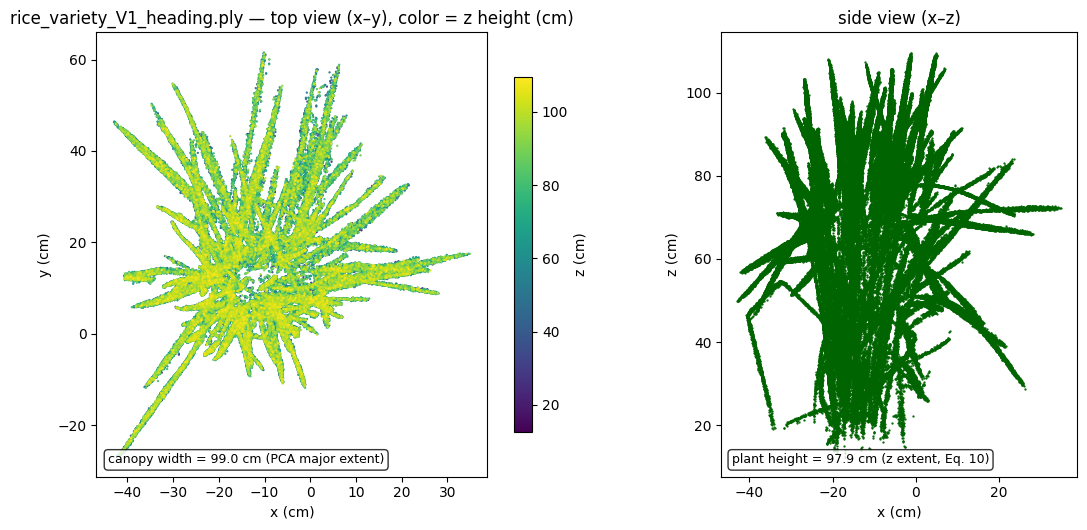

rice_variety_V1_heading.ply: 9,491,029 points (all used for traits); display subsampled to 150,000


In [ ]:
import numpy as np
from plyfile import PlyData
import matplotlib.pyplot as plt

PREVIEW_KEY = 'rice_variety_V1_heading.ply'

def load_points(ply_path):
    # identical filtering to the authors' load_points
    ply = PlyData.read(str(ply_path))
    if 'vertex' not in ply:
        raise ValueError('no vertex element found')
    vertices = ply['vertex'].data
    if not {'x', 'y', 'z'}.issubset(set(vertices.dtype.names or ())):
        raise ValueError('missing x, y, or z coordinates')
    pts = np.column_stack((np.asarray(vertices['x'], np.float64),
                           np.asarray(vertices['y'], np.float64),
                           np.asarray(vertices['z'], np.float64)))
    return pts[np.isfinite(pts).all(axis=1)]

pv = load_points(DATA_DIR / PREVIEW_KEY)
rng = np.random.default_rng(0)
sel = pv[rng.choice(len(pv), size=min(150_000, len(pv)), replace=False)]
xy = pv[:, :2] - pv[:, :2].mean(axis=0)
evals, evec = np.linalg.eigh(np.cov(xy, rowvar=False, bias=True))
major = evec[:, np.argmax(evals)]
height = np.ptp(pv[:, 2])
width = np.ptp((xy @ np.column_stack([major, [-major[1], major[0]]])), axis=0).max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
order = np.argsort(sel[:, 2])
sc = axes[0].scatter(sel[:, 0], sel[:, 1], c=sel[order, 2], s=0.4, cmap='viridis')
axes[0].set_title(f'{PREVIEW_KEY} — top view (x–y), color = z height (cm)')
axes[0].set_xlabel('x (cm)'); axes[0].set_ylabel('y (cm)'); axes[0].set_aspect('equal')
axes[0].annotate(f'canopy width = {width:.1f} cm (PCA major extent)',
                 (0.03, 0.03), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', fc='white', alpha=0.8))
fig.colorbar(sc, ax=axes[0], label='z (cm)', shrink=0.8)
axes[1].scatter(sel[:, 0], sel[:, 2], s=0.4, color='darkgreen')
axes[1].set_title('side view (x–z)')
axes[1].set_xlabel('x (cm)'); axes[1].set_ylabel('z (cm)'); axes[1].set_aspect('equal')
axes[1].annotate(f'plant height = {height:.1f} cm (z extent, Eq. 10)',
                 (0.03, 0.03), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', fc='white', alpha=0.8))
plt.tight_layout(); plt.savefig('/content/point_cloud_preview.png', dpi=140); plt.show()
print(f'{PREVIEW_KEY}: {len(pv):,d} points (all used for traits); display subsampled to {len(sel):,d}')

## Run the authors' script on all eight point clouds

This is the core reproduction: the unmodified, md5-verified author script is executed over the download
directory exactly as its README documents (`python extract_phenotypic_traits.py "<dir>" --unit cm`). It
processes clouds one at a time (peak memory ≈ one cloud) and prints one line per file: point count,
plant height, and canopy width in cm. Expect a few minutes for all eight.

**核心となる再現実行です。** 著者スクリプトを README の使い方どおり（`--unit cm`）
8 点群すべてに対して実行し、各ファイルの点数・株高・冠幅をそのまま出力します。

In [ ]:
import subprocess, sys, time

t0 = time.time()
process = subprocess.Popen(
    [sys.executable, '-u', str(script), str(DATA_DIR), '--unit', 'cm'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, bufsize=1,
)
lines = []
for line in process.stdout:
    print(line, end='', flush=True)
    lines.append(line)
process.stdout.close()
stderr_text = process.stderr.read()
returncode = process.wait(timeout=60)
if returncode != 0:
    print(stderr_text)
    raise RuntimeError(f'author script failed with return code {returncode}')
script_output = ''.join(lines)
assert not any('error=' in line for line in lines), 'author script reported a per-file error'
print(f'[author script completed in {time.time()-t0:.0f} s]')

Found 8 PLY file(s) under /content/metatlas_data


rice_variety_V1_heading.ply: n_points=9491029, plant_height=97.8602 cm, canopy_width=98.9839 cm


rice_variety_V1_maturity.ply: n_points=6778271, plant_height=107.8623 cm, canopy_width=67.4546 cm


rice_variety_V2_heading.ply: n_points=11631495, plant_height=113.1769 cm, canopy_width=83.7221 cm


rice_variety_V2_maturity.ply: n_points=18753535, plant_height=114.5352 cm, canopy_width=96.4184 cm


...

rice_variety_V3_maturity.ply: n_points=11728143, plant_height=116.0926 cm, canopy_width=70.6352 cm


rice_variety_V4_heading.ply: n_points=12948198, plant_height=105.9865 cm, canopy_width=110.2047 cm


rice_variety_V4_maturity.ply: n_points=12304551, plant_height=87.4915 cm, canopy_width=84.0345 cm


Completed: 8 successful, 0 failed


[author script completed in 18 s]


## Tabulate the extracted traits and export CSV

The script's printed lines are parsed into a table (one row per deposited cloud), displayed, and saved to
`/content/extracted_traits.csv` for further use. These are the values computed by the authors' method —
nothing here is hand-entered.

**スクリプトの出力を表に整理し、CSV に保存します。** 行は沈着した 8 点群に対応します。

In [ ]:
import re
import pandas as pd

rows = []
pat = re.compile(r'(\S+\.ply): n_points=(\d+), plant_height=([\d.]+) cm, canopy_width=([\d.]+) cm')
for line in script_output.splitlines():
    m = pat.search(line)
    if m:
        name = pathlib.PurePosixPath(m.group(1)).name
        cultivar, stage = name[len('rice_variety_'):-len('.ply')].rsplit('_', 1)
        assert stage in ('heading', 'maturity') and cultivar.startswith('V'), name
        rows.append(dict(file=name, cultivar=cultivar, stage=stage,
                         n_points=int(m.group(2)),
                         plant_height_cm=float(m.group(3)),
                         canopy_width_cm=float(m.group(4))))
traits = pd.DataFrame(rows)
assert len(traits) == 8, traits
display(traits)
traits.to_csv('/content/extracted_traits.csv', index=False)
print('saved: /content/extracted_traits.csv')

,file,cultivar,stage,n_points,plant_height_cm,canopy_width_cm
0,rice_variety_V1_heading.ply,V1,heading,9491029,97.8602,98.9839
1,rice_variety_V1_maturity.ply,V1,maturity,6778271,107.8623,67.4546
2,rice_variety_V2_heading.ply,V2,heading,11631495,113.1769,83.7221
3,rice_variety_V2_maturity.ply,V2,maturity,18753535,114.5352,96.4184
4,rice_variety_V3_heading.ply,V3,heading,11196776,113.0601,78.8823
5,rice_variety_V3_maturity.ply,V3,maturity,11728143,116.0926,70.6352
6,rice_variety_V4_heading.ply,V4,heading,12948198,105.9865,110.2047
7,rice_variety_V4_maturity.ply,V4,maturity,12304551,87.4915,84.0345


saved: /content/extracted_traits.csv


## Growth-stage comparison of the extracted traits (additional visualization)

A grouped bar chart comparing plant height and canopy width between the heading and maturity stages for
each cultivar, **created for this notebook from the extracted table above** (not a figure reproduced from
the paper). It makes the expected stage effect — taller and wider plants at maturity — directly visible.

**抽出結果の表から作成した補足グラフです（論文図の再現ではありません）。**
品種ごとに抽穂期と成熟期の株高・冠幅を比較します。

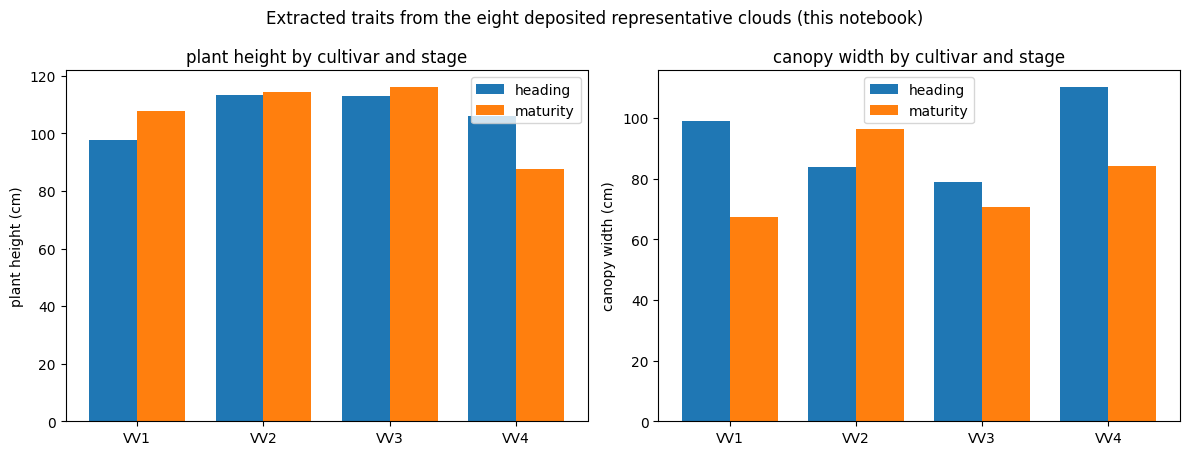

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
width_px = 0.38
cultivars = sorted(traits['cultivar'].unique())
for ax, col, label in [(axes[0], 'plant_height_cm', 'plant height (cm)'),
                       (axes[1], 'canopy_width_cm', 'canopy width (cm)')]:
    for i, stage in enumerate(['heading', 'maturity']):
        sub = traits[traits['stage'] == stage].set_index('cultivar').loc[cultivars]
        ax.bar([c + (i - 0.5) * width_px for c in range(len(cultivars))], sub[col],
               width=width_px, label=stage)
    ax.set_xticks(range(len(cultivars)), [f'V{c}' for c in cultivars])
    ax.set_ylabel(label); ax.set_title(f'{label.split(" (")[0]} by cultivar and stage')
    ax.legend()
plt.suptitle('Extracted traits from the eight deposited representative clouds (this notebook)')
plt.tight_layout(); plt.savefig('/content/trait_stage_comparison.png', dpi=140); plt.show()

## Comparison with the paper's reported trait-validation accuracy (context only)

Section 3.4 of the paper (Figure 6) reports, for 24 plant-stage observations with manual measurements:
plant height R² = 0.989, RMSE = 2.082 cm; canopy width R² = 0.946, RMSE = 4.604 cm. **The per-observation
manual values are not deposited**, so these aggregates cannot be recomputed here; the eight extracted
clouds are 8 representative members of that 24-observation set. We print the extracted ranges as a
plausibility summary only — a successful run does not verify the paper's dataset-level accuracy.

**参考:論文 §3.4 の集計精度（手測値 24 観測, Fig. 6）。** 個々の手測値は非公開のため再計算は
できず、ここでは抽出値の範囲を確認するにとどめます（データセット全体精度の検証ではありません）。

In [ ]:
print('Extracted (this notebook, authors\' method, 8 representative clouds):')
print(traits.groupby('stage')[['plant_height_cm', 'canopy_width_cm']].agg(['min', 'max']).round(1))
print()
print('Paper-reported aggregate accuracy (§3.4, 24 observations, manual vs point-cloud-derived):')
print('  plant height : R^2 = 0.989, RMSE = 2.082 cm')
print('  canopy width : R^2 = 0.946, RMSE = 4.604 cm')
print('  (per-observation manual values are not deposited; these are cited context, not recomputed)')

Extracted (this notebook, authors' method, 8 representative clouds):
         plant_height_cm        canopy_width_cm       
                     min    max             min    max
stage                                                 
heading             97.9  113.2            78.9  110.2
maturity            87.5  116.1            67.5   96.4

Paper-reported aggregate accuracy (§3.4, 24 observations, manual vs point-cloud-derived):
  plant height : R^2 = 0.989, RMSE = 2.082 cm
  canopy width : R^2 = 0.946, RMSE = 4.604 cm
  (per-observation manual values are not deposited; these are cited context, not recomputed)


## Verify the deposited CBAM-UNet checkpoint — and why inference is not executed

The record also contains `CBAM-UNet.zip` (model source GPLv3, trained checkpoint CC BY 4.0, minimal
inference script and preprocessing docs). We download and MD5-verify the archive and list its members.
The 70-epoch checkpoint `weights/best_model_cbam_skip_70.pth` matches the checkpoint selected in the
paper (§3.1). **However, no input image is deposited anywhere**: the archive contains no image
(`IMAGES: []`), and the raw multi-view photographs used for segmentation are absent from the record, so a
scientifically valid inference sample does not exist. **The inference is therefore NOT executed** — no
substitute input is invented.

**CBAM-UNet.zip を MD5 検証付きで取得し内容を一覧します。** 70 エポック_CHECKPOINT は論文 §3.1
の選択と一致しますが、**アーカイブ内にもレコード中にも入力画像が存在しないため、推論は実行しません**
（代用画像は使用しません）。

In [ ]:
import zipfile

ZIP_KEY = 'CBAM-UNet.zip'
zf_path = fetch(ZIP_KEY)  # same verified download helper as the point clouds
with zipfile.ZipFile(zf_path) as zf:
    names = zf.namelist()
    print(f'{ZIP_KEY}: {len(names)} members')
    for n in sorted(names):
        print(f'  {n}')
    images = [n for n in names if n.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
    print()
    print('bundled sample images:', images if images else 'NONE')
    req = zf.read('CBAM-UNet/requirements.txt').decode()
    print('author inference requirements:', req.strip())
    infer_head = zf.read('CBAM-UNet/inference.py').decode().splitlines()[:14]
    print('inference.py (first 14 lines):'); print('\n'.join(infer_head))
assert not images, 'unexpected bundled image — revisit the inference decision'
print()
print('CONCLUSION: checkpoint verified, but no valid input image exists in public materials;')
print('             CBAM-UNet inference is NOT executed in this reproduction.')

  ok: CBAM-UNet.zip (50 MB, md5 verified, 42 s)


CBAM-UNet.zip: 13 members
  CBAM-UNet/
  CBAM-UNet/LICENSE
  CBAM-UNet/LICENSES.md
  CBAM-UNet/README.md
  CBAM-UNet/inference.py
  CBAM-UNet/model/
  CBAM-UNet/model/CBAM.py
  CBAM-UNet/model/__init__.py
  CBAM-UNet/model/unet_model.py
  CBAM-UNet/model/unet_parts.py
  CBAM-UNet/requirements.txt
  CBAM-UNet/weights/
  CBAM-UNet/weights/best_model_cbam_skip_70.pth

bundled sample images: NONE
author inference requirements: torch==1.10.0
numpy
opencv-python
inference.py (first 14 lines):
#!/usr/bin/env python3
"""Minimal reproducible inference script for the released CBAM-UNet.

The script follows the preprocessing used to train the supplied single-channel
checkpoint:

1. Read the color image with OpenCV (BGR channel order).
2. Resize it to 512 x 512 with bilinear interpolation (INTER_LINEAR).
3. Convert it to one-channel grayscale with COLOR_BGR2GRAY.
4. Convert it to float32 without division by 255 or mean/SD normalization.

The network returns a one-channel raw-logit map. Values grea

## Validation record, limitations, and references

**Executed scope:** the authors' trait-extraction method (paper Eq. 10 + PCA canopy width, §3.4) was run
unmodified on the eight deposited representative point clouds; all downloads MD5-verified; results
tabulated and exported. Executed end-to-end on a fresh Colab CPU runtime (validation date recorded in the
accompanying report).

**Limitations:** one-example-scale demonstration — it does not verify the paper's dataset-level accuracy
(R²/RMSE are cited context only); the CBAM-UNet inference and all training/reconstruction/optimization
stages are not reproduced (materials not public); display plots subsample points for legibility while
traits always use all points.

**References**
- Paper: DOI [10.3389/fpls.2026.1882534](https://doi.org/10.3389/fpls.2026.1882534), Frontiers in Plant Science, 2026.
- Data & code: Zenodo record [22016319](https://zenodo.org/records/22016319) v2.2 (CC BY 4.0; script MIT; model source GPLv3, checkpoint CC BY 4.0).
- Pipeline context: COLMAP 3.10 + OpenMVS 2.1.0 with default parameters (record README).

**検証記録と参考文献。** 本ノートブックは新しい Colab CPU ランタイムで最初から最後まで実行・検証
されています。単一規模の実演であり、論文のデータセット精度（R²/RMSE）の検証ではありません。